In [57]:
# training rough model

import os
import json
from pathlib import Path

import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [58]:

DATA_DIR = Path("../data/processed/augmented")
FIGURE_DIR = '../outputs/figures'
PLOTS_DIR = '../outputs/figures/plots'
MODEL_DIR = Path("../outputs/models")
OUTPUT_DIR = Path("../outputs")

ACTIVE_STAGE = "stage01"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)



In [59]:
SEED = 42
EPOCHS = 100
BATCH_SIZE = 4

# POSITIVE_CLASS_WEIGHT = 0.5
# POSITIVE_CLASS_WEIGHT = 1.0
# POSITIVE_CLASS_WEIGHT = 1.5
POSITIVE_CLASS_WEIGHT = 2.0

EARLY_STOPPING_PATIENCE = 15

tf.keras.utils.set_random_seed(SEED)

X_train = np.load(DATA_DIR / "XtrainAug.npy").astype(np.float32)
X_val = np.load(DATA_DIR / "XVal.npy").astype(np.float32)
Y_train = np.load(DATA_DIR / "YtrainAug.npy").astype(np.float32)
Y_val = np.load(DATA_DIR / "YVal.npy").astype(np.float32)

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype, "min/max:", X_train.min(), X_train.max())
print("X_val shape:", X_val.shape, "dtype:", X_val.dtype, "min/max:", X_val.min(), X_val.max())
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype, "min/max:", Y_train.min(), Y_train.max())
print("Y_val shape:", Y_val.shape, "dtype:", Y_val.dtype, "min/max:", Y_val.min(), Y_val.max())

print("Training foreground ratio:", float(Y_train.mean()))
print("Validation foreground ratio:", float(Y_val.mean()))

X_train shape: (432, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
X_val shape: (28, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y_train shape: (432, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y_val shape: (28, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Training foreground ratio: 0.1822669357061386
Validation foreground ratio: 0.15096119046211243


In [39]:
# # simple unet model
# # inputs → encoder → bottleneck → decoder → sigmoid mask

# def build_unet(input_shape=(256, 256, 1)):
#     inputs = layers.Input(input_shape)

#     # Encoder
#     c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
#     c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
#     p1 = layers.MaxPooling2D()(c1)

#     c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
#     c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
#     p2 = layers.MaxPooling2D()(c2)

#     # Bottleneck
#     b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
#     b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(b1)

#     # Decoder
#     u1 = layers.UpSampling2D()(b1)
#     u1 = layers.concatenate([u1, c2])
#     c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
#     c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

#     u2 = layers.UpSampling2D()(c3)
#     u2 = layers.concatenate([u2, c1])
#     c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
#     c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

#     outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

#     return models.Model(inputs, outputs, name="bubble_unet")

In [40]:
# 4-level unet model
# inputs → encoder (4 levels) → bottleneck → decoder (4 levels) → sigmoid mask

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck (16x16 spatial resolution)
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(p4)
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(b1)

    # Decoder
    u4 = layers.UpSampling2D()(b1)
    u4 = layers.concatenate([u4, c4])
    d4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u4)
    d4 = layers.Conv2D(128, 3, activation='relu', padding='same')(d4)

    u3 = layers.UpSampling2D()(d4)
    u3 = layers.concatenate([u3, c3])
    d3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)
    d3 = layers.Conv2D(64, 3, activation='relu', padding='same')(d3)

    u2 = layers.UpSampling2D()(d3)
    u2 = layers.concatenate([u2, c2])
    d2 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    d2 = layers.Conv2D(32, 3, activation='relu', padding='same')(d2)

    u1 = layers.UpSampling2D()(d2)
    u1 = layers.concatenate([u1, c1])
    d1 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    d1 = layers.Conv2D(16, 3, activation='relu', padding='same')(d1)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)

    return models.Model(inputs, outputs, name="bubble_unet4")

In [41]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * POSITIVE_CLASS_WEIGHT + 1
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [42]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [43]:
model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coef, iou_coef]
)
model.summary()


Model: "bubble_unet4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 1,962,337 (7.49 MB)

 Trainable params: 1,962,337 (7.49 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# checkpoint the best epoch, stop when validation stalls, lower LR on plateau

BEST_WEIGHTS_PATH = os.path.join(MODEL_DIR, f"{ACTIVE_STAGE}bubble_unet_best.weights.h5")
HISTORY_CSV_PATH = os.path.join(OUTPUT_DIR, f"{ACTIVE_STAGE}training_history.csv")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_WEIGHTS_PATH),
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(HISTORY_CSV_PATH)),
]

In [45]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks
)

# all later evaluation must use the best checkpointed epoch, not the last one
model.load_weights(BEST_WEIGHTS_PATH)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - dice_coef: 0.1412 - iou_coef: 0.0774 - loss: 1.5938
Epoch 1: val_dice_coef improved from None to 0.16515, saving model to ../outputs/models/stage00bubble_unet_best.weights.h5

Epoch 1: finished saving model to ../outputs/models/stage00bubble_unet_best.weights.h5
108/108 ━━━━━━━━━━━━━━━━━━━━ 43s 370ms/step - dice_coef: 0.1373 - iou_coef: 0.0748 - loss: 1.5500 - val_dice_coef: 0.1651 - val_iou_coef: 0.0904 - val_loss: 1.5253 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - dice_coef: 0.1580 - iou_coef: 0.0869 - loss: 1.4581
Epoch 2: val_dice_coef improved from 0.16515 to 0.19512, saving model to ../outputs/models/stage00bubble_unet_best.weights.h5

Epoch 2: finished saving model to ../outputs/models/stage00bubble_unet_best.weights.h5
108/108 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - dice_coef: 0.1607 - iou_coef: 0.0885 - loss: 1.4438 - val_dice_coef: 0.1951 - val_iou_coef: 0.1088 - val_loss: 1.4480 -

In [50]:
# MODEL_PATH = MODEL_DIR / "bubble_unet.keras"
MODEL_PATH = os.path.join(MODEL_DIR, f"{ACTIVE_STAGE}bubble_unet.keras")
HISTORY_PATH = os.path.join(OUTPUT_DIR, f"{ACTIVE_STAGE}training_history.json")

model.save(MODEL_PATH)
serializable_history = {
    name: [float(value) for value in values]
    for name, values in history.history.items()
}
with open(HISTORY_PATH, "w") as history_file:
    json.dump(serializable_history, history_file, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved training history to:", HISTORY_PATH)

Saved model to: ../outputs/models/stage00bubble_unet.keras
Saved training history to: ../outputs/stage00training_history.json


In [60]:
# for previously trained model

if model is None:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)


In [61]:
preds_val = model.predict(X_val)

print("Prediction min:", preds_val.min())
print("Prediction max:", preds_val.max())
print("Prediction mean:", preds_val.mean())
print("Ground truth foreground ratio:", Y_val.mean())

def dice_at_threshold(y_true, y_pred, threshold):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred_bin) + 1)

for t in np.arange(0.25, 0.50, 0.025):
    d = dice_at_threshold(Y_val, preds_val, t)
    fg = (preds_val > t).mean()
    print(f"Threshold {t:.3f} | Dice: {d:.4f} | Pred foreground: {fg:.4f}")
    
# for t in [0.2, 0.3, 0.4, 0.5]:
#     print(f"Foreground ratio at threshold {t}:", (preds_val > t).mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step
Prediction min: 0.0
Prediction max: 1.0
Prediction mean: 0.09171748
Ground truth foreground ratio: 0.15096119
Threshold 0.250 | Dice: 0.7133 | Pred foreground: 0.0941
Threshold 0.275 | Dice: 0.7134 | Pred foreground: 0.0937
Threshold 0.300 | Dice: 0.7135 | Pred foreground: 0.0935
Threshold 0.325 | Dice: 0.7135 | Pred foreground: 0.0932
Threshold 0.350 | Dice: 0.7134 | Pred foreground: 0.0929
Threshold 0.375 | Dice: 0.7134 | Pred foreground: 0.0927
Threshold 0.400 | Dice: 0.7133 | Pred foreground: 0.0925
Threshold 0.425 | Dice: 0.7132 | Pred foreground: 0.0922
Threshold 0.450 | Dice: 0.7132 | Pred foreground: 0.0920
Threshold 0.475 | Dice: 0.7132 | Pred foreground: 0.0918


In [62]:
thresholds = np.arange(0.05, 0.951, 0.025)
threshold_results = []

for threshold in thresholds:
    dice = dice_at_threshold(Y_val, preds_val, threshold)
    foreground_ratio = float((preds_val > threshold).mean())
    threshold_results.append(
        (float(threshold), float(dice), foreground_ratio)
    )
    print(
        f"Threshold {threshold:.3f} | Dice: {dice:.4f} | "
        f"Pred foreground: {foreground_ratio:.4f}"
    )

best_threshold, best_dice, best_foreground_ratio = max(
    threshold_results,
    key=lambda result: result[1]
)

threshold_summary = {
    "best_threshold": best_threshold,
    "validation_dice": best_dice,
    "predicted_foreground_ratio": best_foreground_ratio,
    "ground_truth_foreground_ratio": float(Y_val.mean()),
}
# with (OUTPUT_DIR / "threshold_summary.json").open("w") as summary_file:
#     json.dump(threshold_summary, summary_file, indent=2)

print("\nBest validation threshold:", best_threshold)
print("Best validation Dice:", best_dice)
print("Best foreground ratio:", best_foreground_ratio)


Threshold 0.050 | Dice: 0.7097 | Pred foreground: 0.0992
Threshold 0.075 | Dice: 0.7111 | Pred foreground: 0.0978
Threshold 0.100 | Dice: 0.7120 | Pred foreground: 0.0969
Threshold 0.125 | Dice: 0.7123 | Pred foreground: 0.0962
Threshold 0.150 | Dice: 0.7126 | Pred foreground: 0.0957
Threshold 0.175 | Dice: 0.7128 | Pred foreground: 0.0952
Threshold 0.200 | Dice: 0.7130 | Pred foreground: 0.0948
Threshold 0.225 | Dice: 0.7132 | Pred foreground: 0.0944
Threshold 0.250 | Dice: 0.7133 | Pred foreground: 0.0941
Threshold 0.275 | Dice: 0.7134 | Pred foreground: 0.0937
Threshold 0.300 | Dice: 0.7135 | Pred foreground: 0.0935
Threshold 0.325 | Dice: 0.7135 | Pred foreground: 0.0932
Threshold 0.350 | Dice: 0.7134 | Pred foreground: 0.0929
Threshold 0.375 | Dice: 0.7134 | Pred foreground: 0.0927
Threshold 0.400 | Dice: 0.7133 | Pred foreground: 0.0925
Threshold 0.425 | Dice: 0.7132 | Pred foreground: 0.0922
Threshold 0.450 | Dice: 0.7132 | Pred foreground: 0.0920
Threshold 0.475 | Dice: 0.7132 

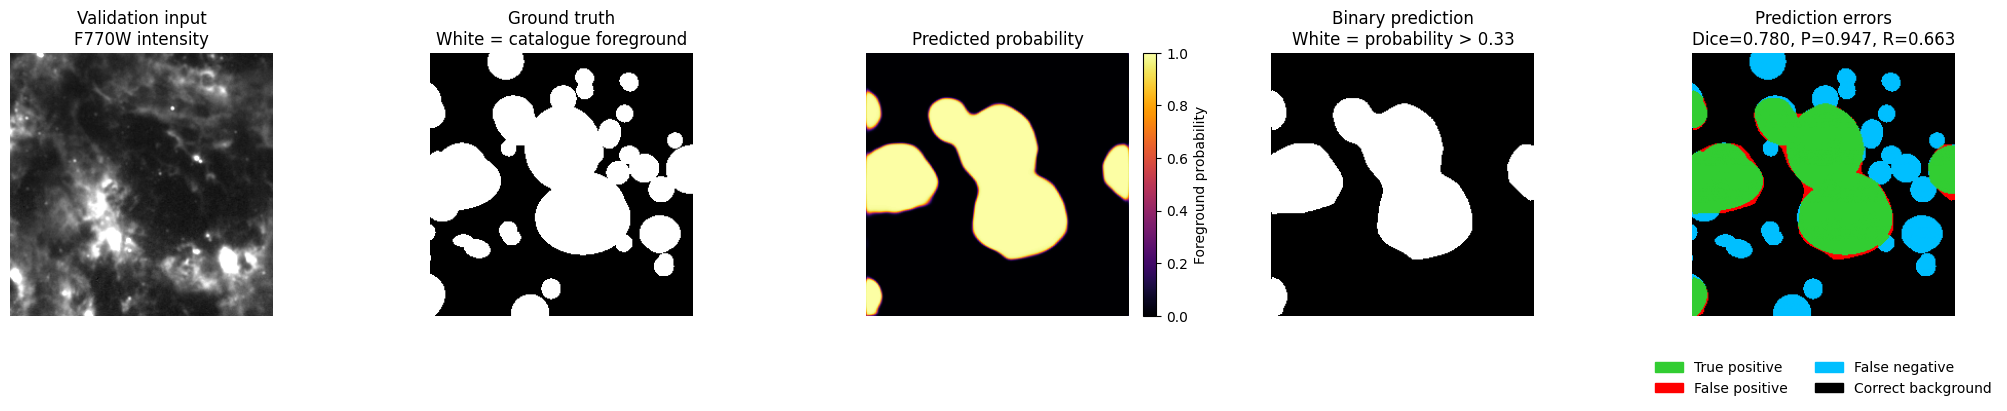

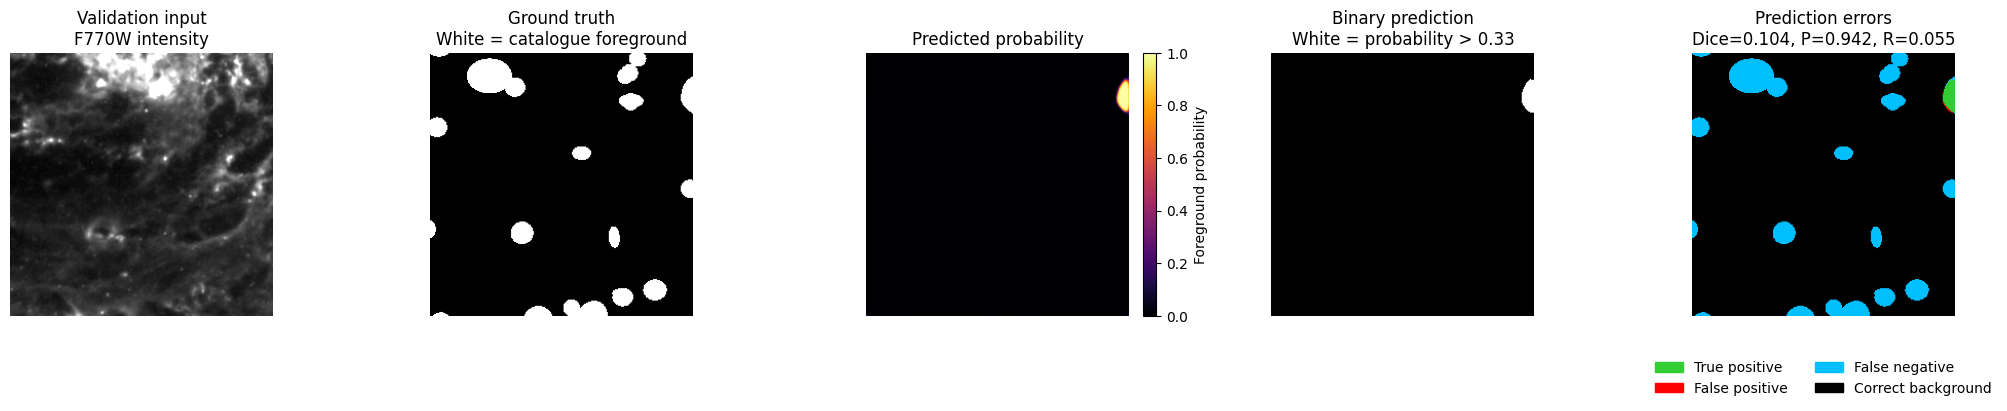

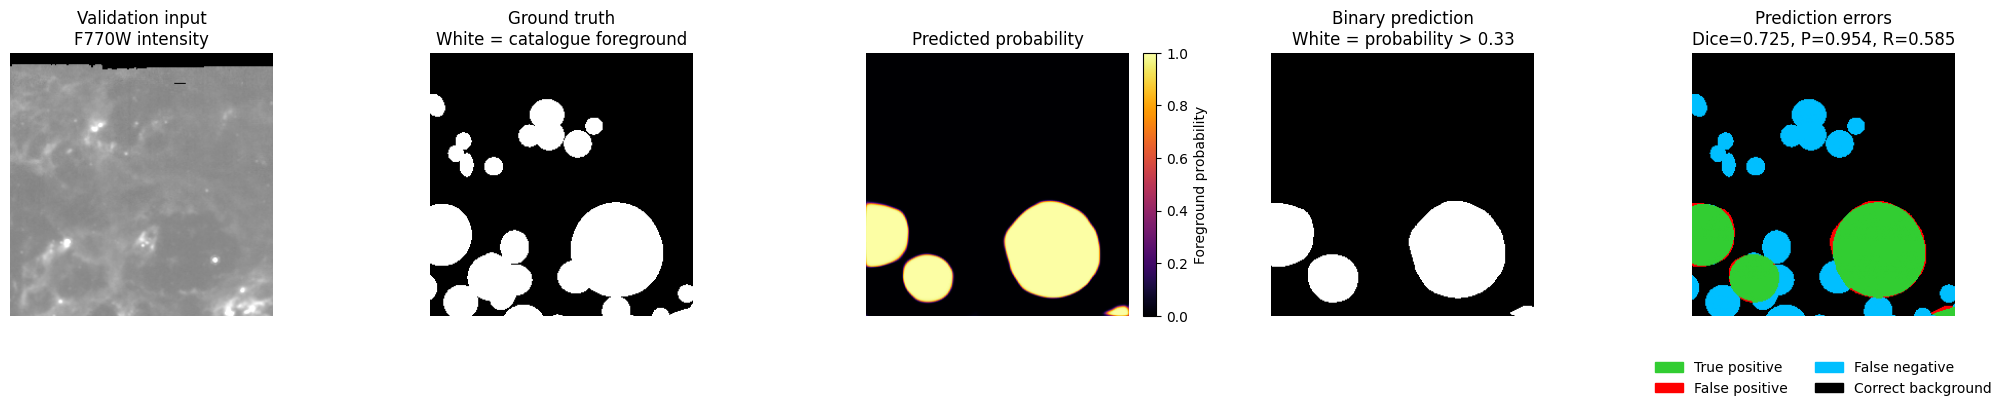

In [63]:
for idx in [0, 10, 20]:
    image = X_val[idx].squeeze()
    ground_truth = Y_val[idx].squeeze() > 0.5
    probability = preds_val[idx].squeeze()
    prediction = probability > best_threshold

    tp = ground_truth & prediction
    fp = ~ground_truth & prediction
    fn = ground_truth & ~prediction

    tp_count = tp.sum()
    fp_count = fp.sum()
    fn_count = fn.sum()

    precision = tp_count / (tp_count + fp_count + 1e-8)
    recall = tp_count / (tp_count + fn_count + 1e-8)
    dice = (
        2 * tp_count /
        (2 * tp_count + fp_count + fn_count + 1e-8)
    )

    # 0 = correct background
    # 1 = true positive
    # 2 = false positive
    # 3 = false negative
    comparison = np.zeros(ground_truth.shape, dtype=np.uint8)
    comparison[tp] = 1
    comparison[fp] = 2
    comparison[fn] = 3

    comparison_cmap = ListedColormap([
        "black",       # correct background
        "limegreen",   # true positive
        "red",         # false positive
        "deepskyblue"  # false negative
    ])

    fig, axes = plt.subplots(1, 5, figsize=(21, 4))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Validation input\nF770W intensity")

    axes[1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1].set_title("Ground truth\nWhite = catalogue foreground")

    probability_plot = axes[2].imshow(
        probability,
        cmap="inferno",
        vmin=0,
        vmax=1
    )
    axes[2].set_title("Predicted probability")

    colorbar = fig.colorbar(
        probability_plot,
        ax=axes[2],
        fraction=0.046,
        pad=0.04
    )
    colorbar.set_label("Foreground probability")

    axes[3].imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[3].set_title(
        f"Binary prediction\n"
        f"White = probability > {best_threshold:.2f}"
    )

    axes[4].imshow(
        comparison,
        cmap=comparison_cmap,
        vmin=0,
        vmax=3
    )
    axes[4].set_title(
        f"Prediction errors\n"
        f"Dice={dice:.3f}, P={precision:.3f}, R={recall:.3f}"
    )

    legend_items = [
        Patch(color="limegreen", label="True positive"),
        Patch(color="red", label="False positive"),
        Patch(color="deepskyblue", label="False negative"),
        Patch(color="black", label="Correct background")
    ]

    axes[4].legend(
        handles=legend_items,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.35),
        ncol=2,
        frameon=False
    )

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

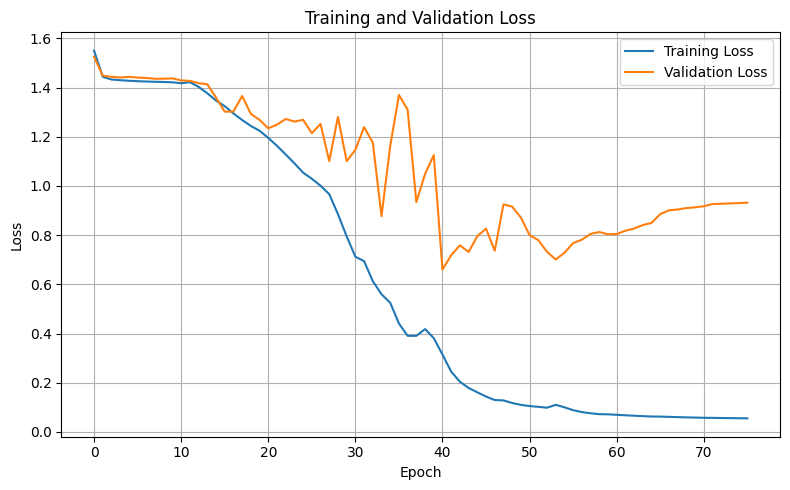

In [64]:
# Loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "loss_curve.png"), dpi=300)
plt.show()

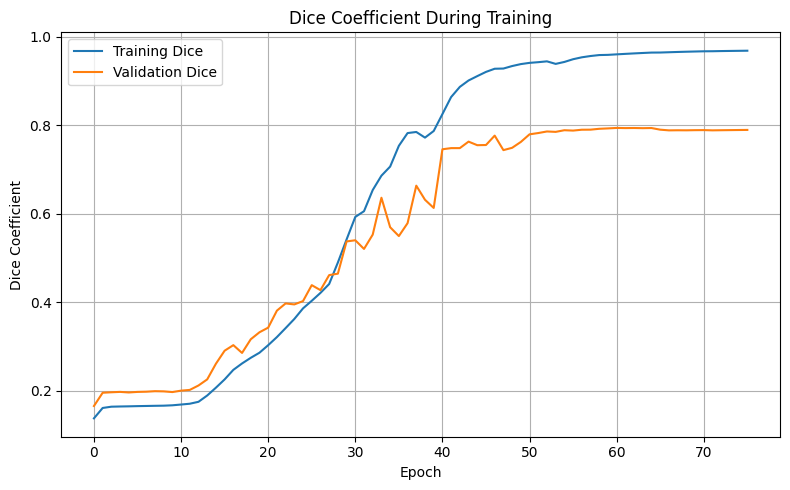

In [65]:
plt.figure(figsize=(8,5))
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')

plt.title('Dice Coefficient During Training')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "dice_curve.png"), dpi=300)
plt.show()